**Load Basic Libraries**

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Load male_blobs dataset from sklearn library**

In [41]:
from sklearn.datasets import make_blobs

In [42]:
x,y = make_blobs(n_samples=1000, n_features=2, centers=1, random_state=23, cluster_std=2.0)

In [43]:
x

array([[ 0.52614556,  8.75136291],
       [-2.15104954,  8.23286685],
       [-2.14365846,  8.00003618],
       ...,
       [ 0.22794962,  9.12036227],
       [ 2.75809847,  7.35617704],
       [ 0.7751279 , 11.14105029]])

In [44]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [45]:
x.size

2000

In [46]:
y.shape

(1000,)

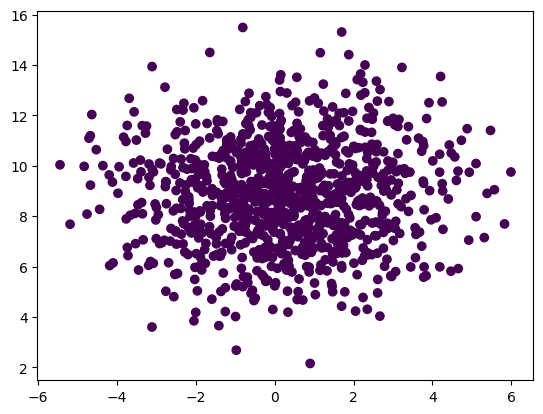

In [47]:
plt.scatter(x[:,0], x[:,1], c=y)

**Split Data in train and test variable**

In [48]:
from sklearn.model_selection import train_test_split\

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=43)

In [49]:
x_train

array([[ 0.78436983,  7.3555548 ],
       [-0.74043153, 12.55448052],
       [ 0.13684234,  7.88795404],
       ...,
       [ 0.14377185,  7.81117282],
       [ 0.42387135,  9.7191113 ],
       [-0.65132696,  8.28189876]])

In [50]:
x_train[1].max()

np.float64(12.554480518657094)

In [51]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

**Model Building**

In [52]:
from sklearn.cluster import KMeans

**Best Vlaue of K by using Elbow Method**

In [56]:
k_range = range(1, 15)
wcss = []

for k in k_range:
  kmean = KMeans(n_clusters=k, init="k-means++")
  kmean.fit(x_train)
  wcss.append(kmean.inertia_)

In [57]:
wcss

[1399.9999999999993,
 940.7859009875801,
 651.6596591741607,
 504.6367092317385,
 425.4042440387085,
 348.26466275807604,
 302.7978083057605,
 272.3068033149808,
 240.84650427490368,
 217.47505349939527,
 200.36970557368878,
 183.67514247570278,
 170.78111626191978,
 161.39617123057036]

**Elbow Graph**

Text(0, 0.5, 'WCSS')

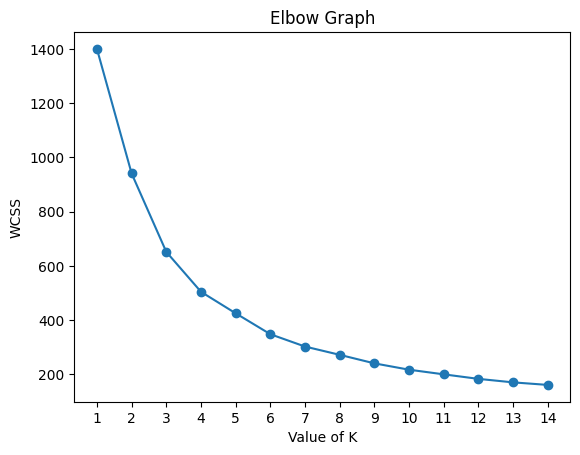

In [62]:
plt.plot(k_range, wcss, marker="o")
plt.title("Elbow Graph")
plt.xticks(k_range)
plt.xlabel("Value of K")
plt.ylabel("WCSS")

**From K = 3**

In [75]:
kmean = KMeans(n_clusters= 10,init="k-means++")
kmean.fit(x_train)
y_lable = kmean.labels_
y_lable

array([1, 0, 7, 9, 6, 0, 5, 7, 2, 9, 9, 1, 7, 7, 2, 2, 4, 3, 3, 1, 1, 7,
       4, 8, 1, 2, 3, 6, 7, 7, 1, 8, 2, 1, 3, 7, 2, 7, 3, 7, 4, 2, 5, 1,
       6, 2, 1, 7, 3, 0, 4, 3, 0, 1, 4, 0, 2, 3, 5, 0, 5, 1, 1, 5, 3, 8,
       3, 2, 9, 1, 3, 8, 5, 8, 7, 9, 7, 8, 7, 7, 4, 2, 6, 5, 5, 2, 3, 5,
       2, 7, 8, 1, 1, 3, 3, 3, 7, 2, 7, 5, 4, 7, 1, 1, 1, 5, 7, 9, 1, 8,
       1, 3, 6, 7, 0, 3, 1, 6, 4, 4, 4, 1, 2, 3, 3, 3, 5, 3, 4, 9, 3, 4,
       0, 6, 2, 2, 7, 9, 2, 7, 3, 4, 2, 5, 2, 9, 3, 4, 3, 6, 6, 2, 6, 8,
       0, 3, 7, 2, 3, 9, 2, 5, 1, 0, 7, 7, 7, 1, 2, 8, 3, 7, 6, 1, 1, 4,
       8, 2, 4, 7, 4, 8, 7, 9, 2, 7, 6, 3, 1, 2, 7, 5, 3, 1, 3, 7, 2, 4,
       6, 1, 3, 1, 1, 9, 7, 1, 0, 7, 4, 6, 5, 2, 0, 0, 4, 1, 3, 6, 2, 4,
       0, 7, 5, 4, 5, 1, 8, 0, 2, 9, 3, 1, 2, 5, 3, 7, 0, 5, 0, 1, 1, 9,
       6, 8, 0, 2, 0, 3, 7, 9, 7, 2, 3, 8, 7, 1, 3, 3, 9, 7, 1, 7, 2, 5,
       2, 2, 3, 2, 2, 6, 5, 6, 3, 5, 9, 8, 6, 6, 2, 7, 0, 3, 1, 5, 0, 5,
       9, 8, 3, 5, 6, 9, 3, 0, 7, 7, 2, 2, 8, 4, 5,

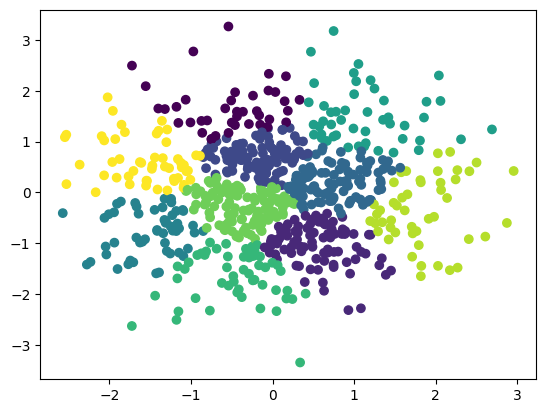

In [76]:
plt.scatter(x_train[:,0], x_train[:,1], c=kmean.labels_)